In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from scipy.optimize import differential_evolution
from collections import deque
import joblib # Para carregar os scalers
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib as plt

In [2]:
def simular_controlador_fuzzy_vetor(
    parametros_vetor, 
    phi_input, 
    l_input, 
    plotar_graficos=False):
    """
    Cria e simula um controlador fuzzy, recebendo os parâmetros
    variáveis como um vetor e retornando as saídas como um vetor.
    """
    try:
        z_dp, pff_dp, mp_dp, pff_m, mp_m = parametros_vetor
    except ValueError:
        raise ValueError(f"O vetor de parâmetros deve conter 5 elementos. Recebido: {len(parametros_vetor)}")

    # Definição das variáveis do universo fuzzy
    PHI = ctrl.Antecedent(np.linspace(-np.pi, np.pi, 181), 'PHI')
    L   = ctrl.Antecedent(np.linspace(0, 5, 181), 'L')
    VF  = ctrl.Consequent(np.linspace(-0.15, 0.15, 181), 'VF')
    WF  = ctrl.Consequent(np.linspace(-0.5, 0.5, 181), 'WF')

    # Criação das funções de pertinência
    PHI['EN']  = fuzz.gaussmf(PHI.universe, -np.pi, z_dp)
    PHI['PNR'] = fuzz.gaussmf(PHI.universe, pff_m - np.pi, pff_dp)
    PHI['GN']  = fuzz.gaussmf(PHI.universe, mp_m - np.pi, mp_dp)
    PHI['MN']  = fuzz.gaussmf(PHI.universe, -mp_m, mp_dp)
    PHI['PNF'] = fuzz.gaussmf(PHI.universe, -pff_m, pff_dp)
    PHI['Z']   = fuzz.gaussmf(PHI.universe, 0, z_dp)
    PHI['PPF'] = fuzz.gaussmf(PHI.universe, pff_m, pff_dp)
    PHI['MP']  = fuzz.gaussmf(PHI.universe, mp_m, mp_dp)
    PHI['GP']  = fuzz.gaussmf(PHI.universe, np.pi - mp_m, mp_dp)
    PHI['PPR'] = fuzz.gaussmf(PHI.universe, np.pi - pff_m, pff_dp)
    PHI['EP']  = fuzz.gaussmf(PHI.universe, np.pi, z_dp)

    L['MP'] = fuzz.zmf(L.universe, 0.01, 0.02)
    L['G']  = fuzz.smf(L.universe, 0.01, 0.02)

    VF['R']  = fuzz.pimf(VF.universe, -0.151, -0.15, -0.1, -0.05)       # borda esquerda -> trap
    VF['MR'] = fuzz.pimf(VF.universe, -0.1, -0.05, -0.05, 0)               # mantém pimf
    VF['P']  = fuzz.pimf(VF.universe, -0.05, 0, 0, 0.05)                   # mantém pimf
    VF['MF'] = fuzz.pimf(VF.universe, 0, 0.05, 0.05, 0.1)                  # mantém pimf
    VF['F']  = fuzz.pimf(VF.universe, 0.05, 0.1, 0.15, 0.151)  
    
    WF['H']  = fuzz.trimf(WF.universe, [-0.5, -0.5, 0])
    WF['N']  = fuzz.trimf(WF.universe, [-0.5, 0, 0.5])
    WF['AH'] = fuzz.trimf(WF.universe, [0, 0.5, 0.5])

    # Definição das Regras
    rules = [
        ctrl.Rule(L['MP'], (VF['P'], WF['N'])),
        ctrl.Rule(PHI['EN']  & L['G'], (VF['R'],  WF['N'])),
        ctrl.Rule(PHI['PNR'] & L['G'], (VF['MR'], WF['AH'])),
        ctrl.Rule(PHI['GN']  & L['G'], (VF['P'],  WF['AH'])),
        ctrl.Rule(PHI['MN']  & L['G'], (VF['P'],  WF['H'])),
        ctrl.Rule(PHI['PNF'] & L['G'], (VF['MF'], WF['H'])),
        ctrl.Rule(PHI['Z']   & L['G'], (VF['F'],  WF['N'])),
        ctrl.Rule(PHI['PPF'] & L['G'], (VF['MF'], WF['AH'])),
        ctrl.Rule(PHI['MP']  & L['G'], (VF['P'],  WF['AH'])),
        ctrl.Rule(PHI['GP']  & L['G'], (VF['P'],  WF['H'])),
        ctrl.Rule(PHI['PPR'] & L['G'], (VF['MR'], WF['H'])),
        ctrl.Rule(PHI['EP']  & L['G'], (VF['R'],  WF['N']))
    ]
    
    # Criação do sistema e simulação
    sistema_fuzzy = ctrl.ControlSystem(rules)
    simulador = ctrl.ControlSystemSimulation(sistema_fuzzy)

    simulador.input['PHI'] = phi_input
    simulador.input['L']   = l_input
    simulador.compute()

    saida_vf = simulador.output['VF']
    saida_wf = simulador.output['WF']

    if plotar_graficos:
        PHI.view(sim=simulador); L.view(sim=simulador)
        VF.view(sim=simulador); WF.view(sim=simulador)

    return np.array([saida_vf, saida_wf])

In [3]:
def simular_malha_fechada(parametros_fuzzy, modelo_rnn, angulos_ideais, 
                          x_scaler_rnn, y_scaler_rnn, timesteps, L_input_constante=1.0):
    """
    Simula a trajetória completa do sistema em malha fechada, aplicando a
    transformação da saída do controlador para as entradas da RNN.
    
    Retorna a trajetória prevista e o histórico das entradas Wd e We.
    """
    # Definição das constantes físicas para a transformação
    R_CONST = 0.034
    L_CONST = 0.123/2

    # Inicialização da simulação
    angulo_atual = angulos_ideais[0]
    angulos_preditos = np.zeros_like(angulos_ideais)
    angulos_preditos[0] = angulo_atual
    
    # --- MUDANÇA 1: Inicializar listas para salvar o histórico de Wd e We ---
    historico_wd = [0.0] # Começa com o valor inicial
    historico_we = [0.0] # Começa com o valor inicial
    
    # O histórico para a entrada da RNN (sequência)
    historico_entradas_rnn = deque(maxlen=timesteps)
    for _ in range(timesteps):
        historico_entradas_rnn.append([0.0, 0.0])

    # Loop principal da simulação
    for i in range(1, len(angulos_ideais)):
        # 1. Calcula o erro
        erro_phi = angulos_ideais[i-1] - angulo_atual

        # 2. Obtém a ação de controle [VF, WF]
        saida_controlador = simular_controlador_fuzzy_vetor(
            parametros_vetor=parametros_fuzzy,
            phi_input=erro_phi,
            l_input=L_input_constante
        )
        vf = saida_controlador[0]
        wf = saida_controlador[1]

        # 3. Transforma a saída do controlador em [Wd, We]
        W_d = (vf + (L_CONST * wf)) /R_CONST 
        W_e = (vf - (L_CONST * wf)) /R_CONST
        
        # --- MUDANÇA 2: Salva os valores de Wd e We calculados ---
        historico_wd.append(W_d)
        historico_we.append(W_e)
        
        entrada_atual_rnn = [W_d, W_e]
        
        # 4. Atualiza o histórico para a entrada sequencial da RNN
        historico_entradas_rnn.append(entrada_atual_rnn)
        
        # 5. Prepara a sequência de entrada para a RNN
        sequencia_entrada = np.array(historico_entradas_rnn)
        sequencia_norm = x_scaler_rnn.transform(sequencia_entrada)
        sequencia_norm_reshaped = sequencia_norm.reshape(1, timesteps, 2)

        # 6. Usa a RNN para prever a MUDANÇA no ângulo
        delta_angulo_norm = modelo_rnn.predict(sequencia_norm_reshaped, verbose=0)
        
        # 7. Denormaliza a previsão
        delta_angulo = y_scaler_rnn.inverse_transform(delta_angulo_norm)
        
        # 8. Atualiza o estado (posição angular)
        angulo_atual = angulo_atual + delta_angulo[0][0] * 0.07
        angulos_preditos[i] = angulo_atual
        
    # --- MUDANÇA 3: Retorna os históricos junto com a trajetória ---
    return angulos_preditos, np.array(historico_wd), np.array(historico_we)

In [4]:
def funcao_custo_simulacao(parametros_fuzzy, modelo_rnn, angulos_ideais, 
                           x_scaler_rnn, y_scaler_rnn, timesteps):
    """
    Função objetivo que o otimizador tentará minimizar.
    """
    # Roda a simulação completa com os parâmetros atuais
    angulos_preditos = simular_malha_fechada(parametros_fuzzy, modelo_rnn, angulos_ideais, 
                                             x_scaler_rnn, y_scaler_rnn, timesteps)
                                             
    # Calcula o Erro Quadrático Médio (MSE) entre as trajetórias
    mse = np.mean((angulos_ideais - angulos_preditos)**2)
    
    # É bom imprimir o resultado de cada tentativa para acompanhar
    print(f"Testando parâmetros... MSE Resultante: {mse:.6f}")
    
    return mse

In [5]:
# 1. Carregar todos os componentes necessários
print("Carregando modelo RNN, scalers e dados ideais...")
modelo_rnn = keras.models.load_model('best_theta_model.keras')
x_scaler_rnn = joblib.load('x_scaler.gz')
y_scaler_rnn = joblib.load('y_scaler.gz')
dados_ideais_df = pd.read_csv('theta_teste.csv')
angulos_ideais = dados_ideais_df['posicao_angular_ideal'].to_numpy()

Carregando modelo RNN, scalers e dados ideais...


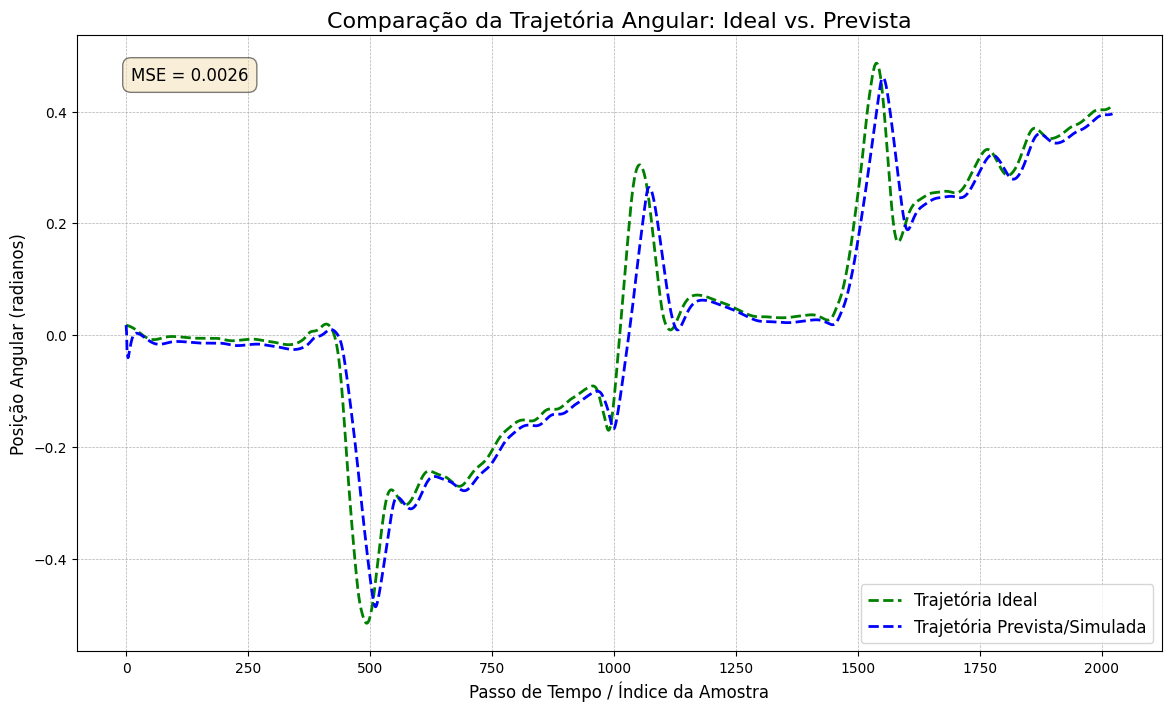

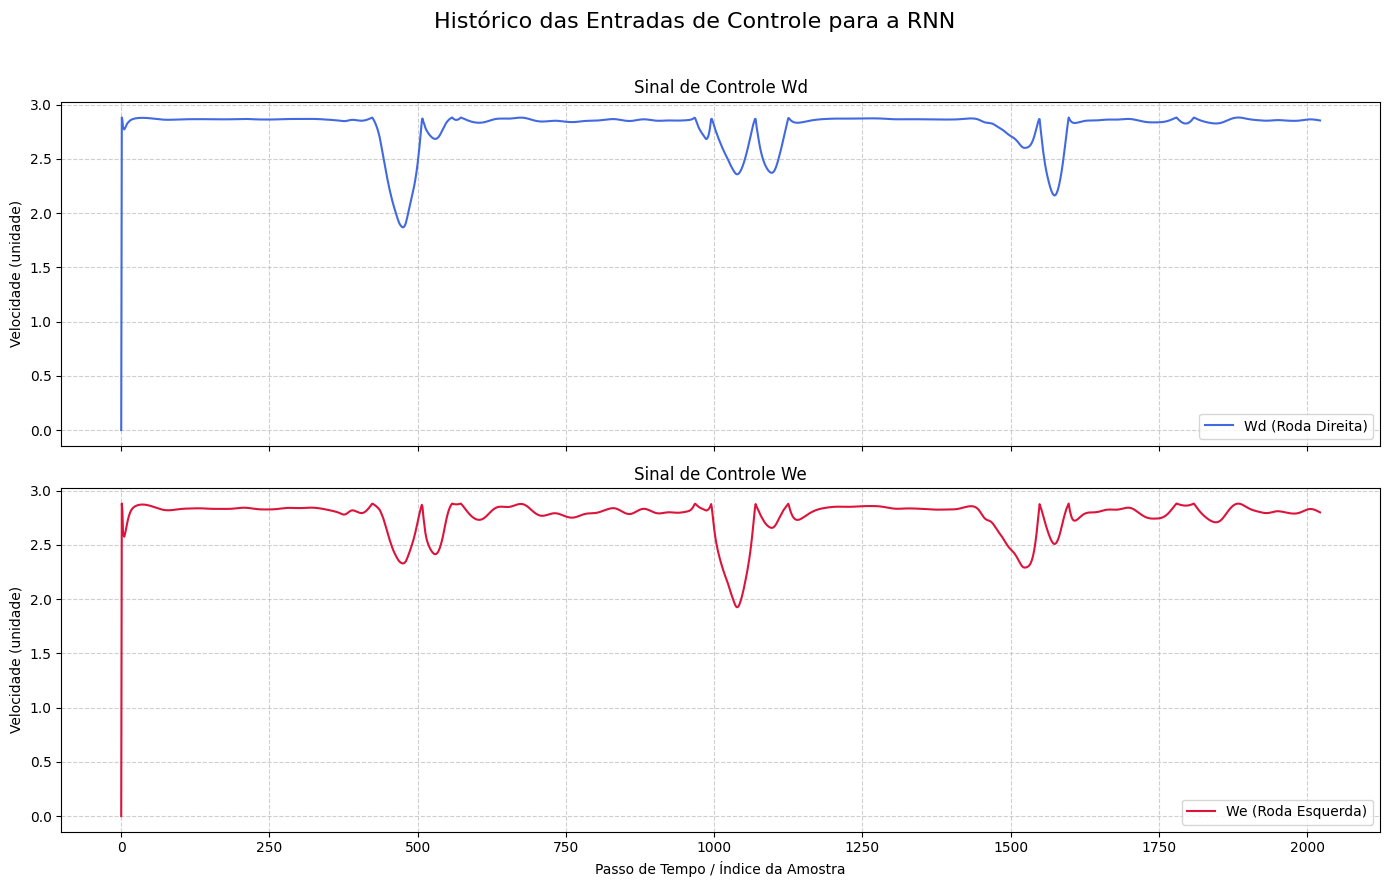

In [6]:
import matplotlib.pyplot as plt
parametros_de_teste = [0.15129693, 0.12799619, 0.00358131, 0.18509992, 0.97523155]
angulos_preditos, Wd_controle, We_controle = simular_malha_fechada(parametros_de_teste, modelo_rnn, angulos_ideais, 
                          x_scaler_rnn, y_scaler_rnn, 3, L_input_constante=3.0)
# 1. Crie a figura e os eixos do gráfico

plt.figure(figsize=(14, 8)) # Define um bom tamanho para a figura

# 2. Plote a trajetória ideal
#    'g--' significa: 'g' = green (verde), '--' = linha tracejada
plt.plot(angulos_ideais, 'g--', label='Trajetória Ideal', linewidth=2)

# 3. Plote a trajetória prevista pelo sistema (controlador + RNN)
#    'b-' significa: 'b' = blue (azul), '-' = linha sólida
plt.plot(angulos_preditos, 'b--', label='Trajetória Prevista/Simulada',linewidth=2)

# 4. Adicione títulos e rótulos para clareza
plt.title('Comparação da Trajetória Angular: Ideal vs. Prevista', fontsize=16)
plt.xlabel('Passo de Tempo / Índice da Amostra', fontsize=12)
plt.ylabel('Posição Angular (radianos)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# 5. (Opcional) Adicione um texto com o erro (MSE) no gráfico
mse = np.mean((angulos_ideais - angulos_preditos)**2)
plt.text(0.05, 0.95, f'MSE = {mse:.4f}', transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))

# 6. Exiba o gráfico
plt.show()

fig, axs = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
fig.suptitle('Histórico das Entradas de Controle para a RNN', fontsize=16)

# 2. Plote Wd_controle no primeiro subplot (axs[0])
axs[0].plot(Wd_controle, color='royalblue', label='Wd (Roda Direita)')
axs[0].set_title('Sinal de Controle Wd')
axs[0].set_ylabel('Velocidade (unidade)')
axs[0].legend()
axs[0].grid(True, linestyle='--', alpha=0.6)

# 3. Plote We_controle no segundo subplot (axs[1])
axs[1].plot(We_controle, color='crimson', label='We (Roda Esquerda)')
axs[1].set_title('Sinal de Controle We')
axs[1].set_ylabel('Velocidade (unidade)')
axs[1].set_xlabel('Passo de Tempo / Índice da Amostra')
axs[1].legend()
axs[1].grid(True, linestyle='--', alpha=0.6)

# 4. Ajusta o layout para evitar sobreposição e exibe o gráfico
plt.tight_layout(rect=[0, 0, 1, 0.96]) # Ajusta para o supertítulo
plt.show()

array([-0.0652736 ,  0.08080764])

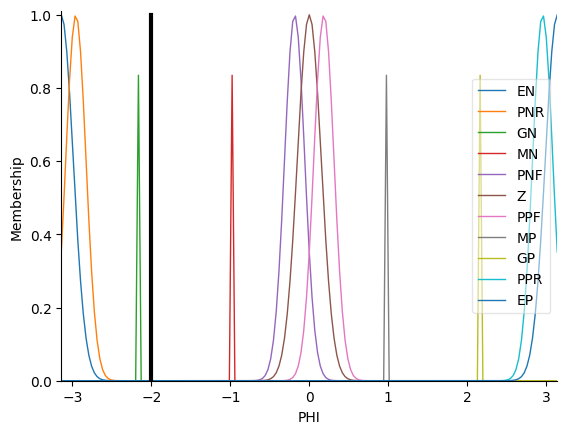

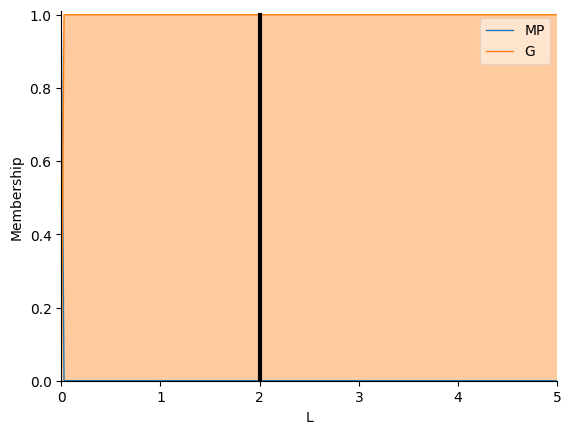

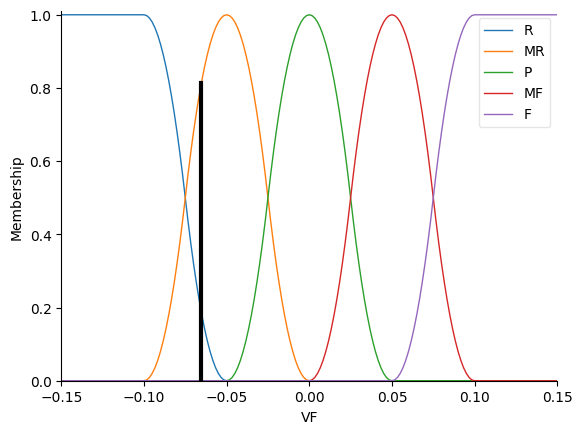

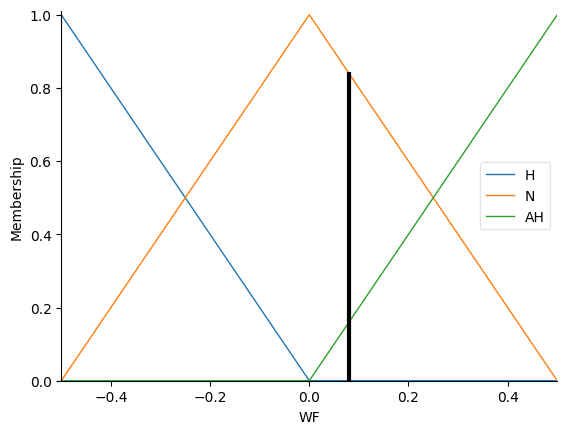

In [8]:
simular_controlador_fuzzy_vetor(parametros_de_teste, -2, 2, plotar_graficos=True)